In [1]:
!pip install vidaug --quiet

In [2]:
# === Cell 1: Setup & Metadata ===

import os
import cv2
import json
import numpy as np
import pandas as pd
from tqdm import tqdm
from vidaug import augmentors as va

# --- Paths ---
primary_video_dir = "/kaggle/input/wlasl-processed/videos"
backup_video_dir = "/kaggle/input/wlasl2000-resized/wlasl-complete/videos"
json_path = "/kaggle/input/wlasl2000-resized/wlasl-complete/nslt_100.json"
class_list_path = "/kaggle/input/wlasl2000-resized/wlasl-complete/wlasl_class_list.txt"
raw_frame_dir = "/kaggle/working/frames_rgb"
os.makedirs(raw_frame_dir, exist_ok=True)

# === INSERTED ===
samuel_video_dir = "/kaggle/input/asl-sam-kimpinde-set2/asl-samuel-kimpinde-dataset-set2/videos"
samuel_metadata_path = "/kaggle/input/asl-sam-kimpinde-set2/asl-samuel-kimpinde-dataset-set2/metadata.csv"

# --- Parameters ---
IMG_SIZE = 64
FPS_TARGETS = [10, 15, 30, 50]
NUM_FRAMES = 24

# --- Load class list ---
idx_to_label = {}
label_to_idx = {}
with open(class_list_path, "r") as f:
    for line in f:
        idx, label = line.strip().split("\t")
        idx = int(idx)
        idx_to_label[idx] = label
        label_to_idx[label] = idx

# --- Load WLASL JSON metadata ---
with open(json_path, "r") as f:
    data = json.load(f)

metadata = {}
for video_id, info in data.items():
    label_idx = info["action"][0]
    label = idx_to_label.get(label_idx, f"unknown_{label_idx}")
    metadata[video_id] = {
        "label": label,
        "primary_path": os.path.join(primary_video_dir, f"{video_id}.mp4"),
        "backup_path": os.path.join(backup_video_dir, f"{video_id}.mp4"),
    }

df_wlasl = pd.DataFrame.from_dict(metadata, orient="index").reset_index().rename(columns={"index": "video_id"})

# === INSERTED: Load Samuel metadata ===
df_samuel = pd.read_csv(samuel_metadata_path)
samuel_records = []
next_idx = max(label_to_idx.values()) + 1

for _, row in df_samuel.iterrows():
    label = row["label"]
    if label not in label_to_idx:
        label_to_idx[label] = next_idx
        idx_to_label[next_idx] = label
        next_idx += 1
    samuel_records.append({
        "video_id": row["filename"].replace(".avi", ""),
        "label": label,
        "primary_path": os.path.join(samuel_video_dir, row["filename"]),
        "backup_path": os.path.join(samuel_video_dir, row["filename"]),
    })

df_samuel = pd.DataFrame(samuel_records)

# === Merge both datasets ===
df = pd.concat([df_wlasl, df_samuel], ignore_index=True)

In [3]:
# === Cell 2: Validation & Balancing ===

valid_videos = []
for _, row in tqdm(df.iterrows(), total=len(df)):
    cap = cv2.VideoCapture(row["primary_path"])
    if not cap.isOpened():
        cap.release()
        cap = cv2.VideoCapture(row["backup_path"])
    path = row["primary_path"] if cap.isOpened() else row["backup_path"]

    if cap.isOpened():
        fps = cap.get(cv2.CAP_PROP_FPS)
        ret, _ = cap.read()
        if ret and fps:
            valid_videos.append({**row, "video_path": path, "fps": fps})
    cap.release()

valid_df = pd.DataFrame(valid_videos)

# --- Downsample Classes with >25 Valid Videos ---
balanced_videos = []
grouped = valid_df.groupby("label")
for label, group in grouped:
    if len(group) >= 18:
        sample_size = min(len(group), 25)
        sampled = group.sample(n=sample_size, random_state=42)
        balanced_videos.append(sampled)

filtered_df = pd.concat(balanced_videos).reset_index(drop=True)
print(f"Balanced dataset contains {len(filtered_df)} videos across {filtered_df['label'].nunique()} classes.")


100%|██████████| 2288/2288 [00:40<00:00, 56.09it/s]


Balanced dataset contains 2181 videos across 100 classes.


In [4]:
# === Cell 3: Augmentation & Keyframe Extraction ===

augment_seq = va.Sequential([
    va.RandomRotate(degrees=10),
    va.GaussianBlur(1.0)
])

def simulate_fps(frames, fps_orig, fps_target):
    step = max(1, int(round(fps_orig / fps_target)))
    return frames[::step]

def hybrid_subsample_pad(frames, target_len=NUM_FRAMES):
    num = len(frames)
    if num >= target_len:
        indices = np.linspace(0, num - 1, target_len).astype(int)
        return np.array([frames[i] for i in indices], dtype=np.float32)
    else:
        pad = [frames[-1]] * (target_len - num)
        return np.array(frames + pad, dtype=np.float32)

for _, row in tqdm(filtered_df.iterrows(), total=len(filtered_df)):
    label_dir = os.path.join(raw_frame_dir, row["label"])
    os.makedirs(label_dir, exist_ok=True)
    video_id = row["video_id"]
    fps_orig = row["fps"]
    cap = cv2.VideoCapture(row["video_path"])

    frames = []
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        frame = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        frame = np.expand_dims(frame, axis=-1).astype(np.float32) / 255.0
        frames.append(frame)
    cap.release()

    if not frames:
        continue

    frames_aug = augment_seq(frames)

    variant_map = {
        f"{video_id}_orig_{int(fps_orig)}fps.npy": hybrid_subsample_pad(frames),
        f"{video_id}_aug_{int(fps_orig)}fps.npy": hybrid_subsample_pad(frames_aug),
    }

    for fps_t in FPS_TARGETS:
        variant_map[f"{video_id}_orig_{fps_t}fps.npy"] = hybrid_subsample_pad(simulate_fps(frames, fps_orig, fps_t))
        variant_map[f"{video_id}_aug_{fps_t}fps.npy"] = hybrid_subsample_pad(simulate_fps(frames_aug, fps_orig, fps_t))

    for name, data in variant_map.items():
        np.save(os.path.join(label_dir, name), data.astype(np.float32))

100%|██████████| 2181/2181 [02:34<00:00, 14.08it/s]


In [5]:

# === Cell 4: Load Dataset & Split ===

from sklearn.model_selection import train_test_split

all_data, all_labels = [], []
available_labels = os.listdir(raw_frame_dir)
label_to_idx = {label: idx for label, idx in label_to_idx.items() if label in available_labels}
idx_to_label = {idx: label for label, idx in label_to_idx.items()}

for label in label_to_idx:
    label_path = os.path.join(raw_frame_dir, label)
    for fname in os.listdir(label_path):
        if fname.endswith(".npy"):
            arr = np.load(os.path.join(label_path, fname))
            all_data.append(arr)
            all_labels.append(label_to_idx[label])

all_data = np.array(all_data, dtype=np.float32)
all_labels = np.array(all_labels)


# --- Stratified Split ---
X_train, X_temp, y_train, y_temp = train_test_split(
    all_data, all_labels, test_size=0.3, stratify=all_labels, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=1/3, stratify=y_temp, random_state=42
)

# --- Save Splits ---
np.save(os.path.join(raw_frame_dir, "X_train.npy"), X_train)
np.save(os.path.join(raw_frame_dir, "y_train.npy"), y_train)
np.save(os.path.join(raw_frame_dir, "X_val.npy"), X_val)
np.save(os.path.join(raw_frame_dir, "y_val.npy"), y_val)
np.save(os.path.join(raw_frame_dir, "X_test.npy"), X_test)
np.save(os.path.join(raw_frame_dir, "y_test.npy"), y_test)

with open(os.path.join(raw_frame_dir, "label_to_idx.json"), "w") as f:
    json.dump(label_to_idx, f)



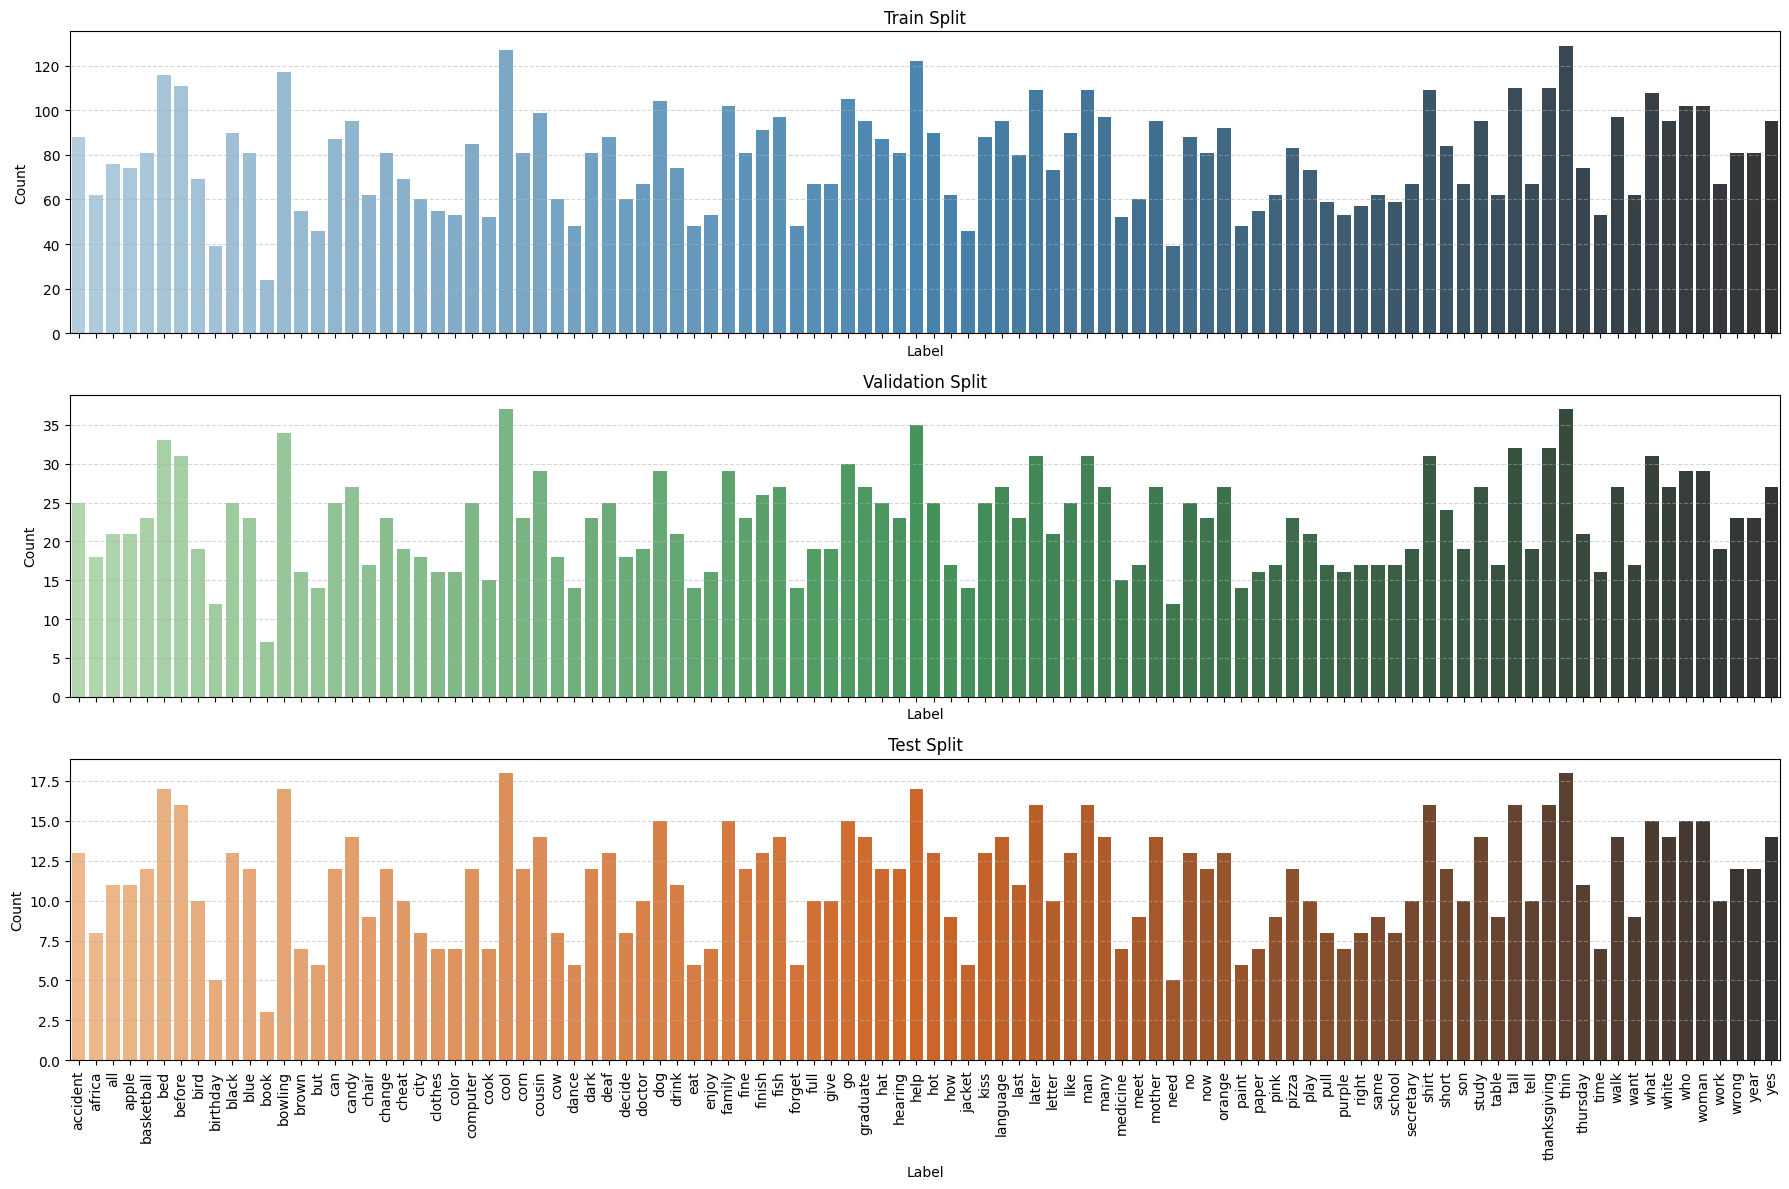

In [6]:
# === Cell 5: Visualize Distribution ===

import matplotlib.pyplot as plt
import seaborn as sns

with open(os.path.join(raw_frame_dir, "label_to_idx.json"), "r") as f:
    label_to_idx = json.load(f)
idx_to_label = {v: k for k, v in label_to_idx.items()}

y_train = np.load(os.path.join(raw_frame_dir, "y_train.npy"))
y_val = np.load(os.path.join(raw_frame_dir, "y_val.npy"))
y_test = np.load(os.path.join(raw_frame_dir, "y_test.npy"))

def count_labels(y):
    counts = np.bincount(y, minlength=len(label_to_idx))
    return pd.DataFrame({
        "Label": [idx_to_label[i] for i in range(len(counts))],
        "Count": counts
    }).sort_values("Label")

df_train = count_labels(y_train)
df_val = count_labels(y_val)
df_test = count_labels(y_test)

def save_barplot(df, title, filename, color):
    plt.figure(figsize=(18, 24))
    sns.barplot(data=df, x="Label", y="Count", palette=color)
    plt.title(title)
    plt.ylabel("Count")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.savefig(os.path.join(raw_frame_dir, filename))
    plt.close()

save_barplot(df_train, "Train Split: Videos per Label", "train_distribution.png", "Blues_d")
save_barplot(df_val, "Validation Split: Videos per Label", "val_distribution.png", "Greens_d")
save_barplot(df_test, "Test Split: Videos per Label", "test_distribution.png", "Oranges_d")

# --- Combined subplot figure ---
fig, axes = plt.subplots(3, 1, figsize=(18, 12), sharex=True)

sns.barplot(data=df_train, x="Label", y="Count", ax=axes[0], palette="Blues_d")
axes[0].set_title("Train Split")
axes[0].set_ylabel("Count")
axes[0].grid(axis="y", linestyle="--", alpha=0.5)

sns.barplot(data=df_val, x="Label", y="Count", ax=axes[1], palette="Greens_d")
axes[1].set_title("Validation Split")
axes[1].set_ylabel("Count")
axes[1].grid(axis="y", linestyle="--", alpha=0.5)

sns.barplot(data=df_test, x="Label", y="Count", ax=axes[2], palette="Oranges_d")
axes[2].set_title("Test Split")
axes[2].set_ylabel("Count")
axes[2].set_xlabel("Label")
axes[2].grid(axis="y", linestyle="--", alpha=0.5)

plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig(os.path.join(raw_frame_dir, "combined_distribution.png"))
plt.show()

In [7]:
import os
import json
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.utils import to_categorical
from collections import Counter

# --- Load splits ---
raw_frame_dir = "/kaggle/working/frames_rgb"
label_map_path = os.path.join(raw_frame_dir, "label_to_idx.json")

X_train = np.load(os.path.join(raw_frame_dir, "X_train.npy"))
y_train = np.load(os.path.join(raw_frame_dir, "y_train.npy"))
X_val = np.load(os.path.join(raw_frame_dir, "X_val.npy"))
y_val = np.load(os.path.join(raw_frame_dir, "y_val.npy"))
X_test = np.load(os.path.join(raw_frame_dir, "X_test.npy"))
y_test = np.load(os.path.join(raw_frame_dir, "y_test.npy"))

with open(label_map_path, "r") as f:
    label_to_idx = json.load(f)

# --- One-hot encode labels ---
num_classes = len(label_to_idx)
y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_val_cat = to_categorical(y_val, num_classes=num_classes)
y_test_cat = to_categorical(y_test, num_classes=num_classes)

# --- TensorFlow Dataset Setup ---
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train_cat))
train_ds = train_ds.shuffle(len(X_train)).batch(BATCH_SIZE).prefetch(AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val_cat))
val_ds = val_ds.cache().batch(BATCH_SIZE).prefetch(AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test_cat))
test_ds = test_ds.cache().batch(BATCH_SIZE).prefetch(AUTOTUNE)


2026-03-02 11:23:30.543067: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772450610.739988      38 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772450610.803507      38 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
I0000 00:00:1772450628.350916      38 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1772450628.353622      38 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability:

In [8]:
import numpy as np
import pandas as pd
from collections import defaultdict
import os

# --- Paths ---
raw_frame_dir = "/kaggle/working/frames_rgb"

# --- Initialize ---
class_counts = defaultdict(int)
frame_lengths = []

# --- Scan Saved .npy Files ---
for label in os.listdir(raw_frame_dir):
    label_path = os.path.join(raw_frame_dir, label)
    if not os.path.isdir(label_path):
        continue
    for fname in os.listdir(label_path):
        if fname.endswith(".npy"):
            arr = np.load(os.path.join(label_path, fname))
            class_counts[label] += 1
            frame_lengths.append(len(arr))

# --- Per-Class Stats ---
df_stats = pd.DataFrame({
    "Label": list(class_counts.keys()),
    "Valid Videos": list(class_counts.values())
}).sort_values("Valid Videos", ascending=False)

# --- Global Stats ---
global_stats = {
    "Total Classes": len(class_counts),
    "Total Valid Videos": sum(class_counts.values()),
    "Mean Frames per Video": np.mean(frame_lengths),
    "Median Frames per Video": np.median(frame_lengths),
    "Min Frames": np.min(frame_lengths),
    "Max Frames": np.max(frame_lengths),
    "Fixed Keyframes per Sample": 5
}

# --- Output ---
print("=== Per-Class Statistics ===")
print(df_stats.to_string(index=False))

print("\n=== Global Statistics ===")
for k, v in global_stats.items():
    print(f"{k}: {v:.2f}" if isinstance(v, float) else f"{k}: {v}")

=== Per-Class Statistics ===
       Label  Valid Videos
        thin           184
        cool           182
        help           174
     bowling           168
         bed           166
      before           158
thanksgiving           158
        tall           158
       shirt           156
       later           156
         man           156
        what           154
          go           150
         dog           148
       woman           146
      family           146
         who           146
      cousin           142
        many           138
        fish           138
        walk           138
         yes           136
    language           136
       study           136
       candy           136
      mother           136
    graduate           136
       white           136
      orange           132
      finish           130
         hot           128
       black           128
        like           128
    accident           126
          no           126

In [9]:
from tensorflow.keras.layers import (
    Input, TimeDistributed, Conv2D, MaxPooling2D,
    Flatten, Conv1D, GlobalAveragePooling1D,
    Dropout, Dense
)
from tensorflow.keras.models import Model

In [10]:
def build_s3d_conv1d(input_shape=(24, 64, 64, 1), num_classes=100):
    inputs = Input(shape=input_shape)
    x = TimeDistributed(Conv2D(12, (3, 3), activation='relu', padding='same'))(inputs)
    x = TimeDistributed(MaxPooling2D((2, 2)))(x)

    x = TimeDistributed(Conv2D(24, (3, 3), activation='relu', padding='same'))(x)
    x = TimeDistributed(MaxPooling2D((2, 2)))(x)

    x = TimeDistributed(Flatten())(x)
    x = Conv1D(48, 3, padding='same', activation='relu')(x)
    x = GlobalAveragePooling1D()(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    return Model(inputs, outputs, name="S3D_Conv1D")

In [11]:
model = build_s3d_conv1d(input_shape=(24, 64, 64, 1), num_classes=100)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "S3D_Conv1D"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 24, 64, 64, 1)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 24, 64, 64, 12) │           120 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 24, 32, 32, 12) │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 24, 32, 32, 24) │         2,616 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ (None, 24, 16, 16, 24) │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_4              │ (None, 24, 6144)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 24, 48)         │       884,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 48)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │         4,900 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 892,420 (3.40 MB)

 Trainable params: 892,420 (3.40 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, CSVLogger, ReduceLROnPlateau

# === Callbacks ===
callbacks = [
    ModelCheckpoint("/kaggle/working/best_S3D_conv1d.h5", save_best_only=True, monitor="val_loss", mode="min", verbose=1),
    EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=1)
]

# === Compile model ===
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=[
        'accuracy',  # This is top-1
        tf.keras.metrics.TopKCategoricalAccuracy(k=3, name='top_3_accuracy'),
        tf.keras.metrics.TopKCategoricalAccuracy(k=5, name='top_5_accuracy')
    ]
)

# === Train ===
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    callbacks=callbacks,
    verbose=1
)

model.load_weights("/kaggle/working/best_S3D_conv1d.h5")

Epoch 1/100


I0000 00:00:1772450671.029739   14079 service.cc:148] XLA service 0x7e90c808cb40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772450671.030802   14079 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1772450671.030823   14079 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1772450672.172140   14079 cuda_dnn.cc:529] Loaded cuDNN version 90300


  3/245 ━━━━━━━━━━━━━━━━━━━━ 13s 57ms/step - accuracy: 0.0000e+00 - loss: 4.6179 - top_3_accuracy: 0.0087 - top_5_accuracy: 0.0278     

I0000 00:00:1772450679.314283   14079 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


245/245 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.0143 - loss: 4.5944 - top_3_accuracy: 0.0434 - top_5_accuracy: 0.0649
Epoch 1: val_loss improved from inf to 4.42872, saving model to /kaggle/working/best_S3D_conv1d.h5
245/245 ━━━━━━━━━━━━━━━━━━━━ 39s 83ms/step - accuracy: 0.0144 - loss: 4.5942 - top_3_accuracy: 0.0435 - top_5_accuracy: 0.0650 - val_accuracy: 0.0531 - val_loss: 4.4287 - val_top_3_accuracy: 0.1224 - val_top_5_accuracy: 0.1599 - learning_rate: 0.0010
Epoch 2/100
245/245 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.0706 - loss: 4.2405 - top_3_accuracy: 0.1459 - top_5_accuracy: 0.2000
Epoch 2: val_loss improved from 4.42872 to 3.81799, saving model to /kaggle/working/best_S3D_conv1d.h5
245/245 ━━━━━━━━━━━━━━━━━━━━ 9s 37ms/step - accuracy: 0.0707 - loss: 4.2400 - top_3_accuracy: 0.1460 - top_5_accuracy: 0.2002 - val_accuracy: 0.1402 - val_loss: 3.8180 - val_top_3_accuracy: 0.2474 - val_top_5_accuracy: 0.3292 - learning_rate: 0.0010
Epoch 3/100
245/245 ━━━━━━━━━━━━━

In [13]:
import tensorflow as tf

# Load model weights
checkpoint_path = "/kaggle/working/best_S3D_conv1d.h5"
model.load_weights(checkpoint_path)

# Evaluate model
results = model.evaluate(test_ds, verbose=1)

print("\nTest Results:")
for name, val in zip(model.metrics_names, results):
    print(f"{name}: {val:.4f}")

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9802 - loss: 0.2055 - top_3_accuracy: 0.9938 - top_5_accuracy: 0.9951

Test Results:
loss: 0.2477
compile_metrics: 0.9848


In [14]:
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd
import numpy as np
import json

# --- Load label mapping ---
raw_frame_dir = "/kaggle/working/frames_rgb"
with open(os.path.join(raw_frame_dir, "label_to_idx.json"), "r") as f:
    label_to_idx = json.load(f)

# --- Predict ---
y_probs = model.predict(test_ds, verbose=1)
y_pred = np.argmax(y_probs, axis=1)

# --- True labels ---
y_true = y_test[:len(y_pred)]

# --- Classification Report ---
# Sort labels by index to match one-hot encoding
target_names = [label for label, idx in sorted(label_to_idx.items(), key=lambda x: x[1])]
report = classification_report(y_true, y_pred, target_names=target_names, output_dict=True)
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=target_names))

# --- Confusion Matrix ---
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:")
print(cm)

# --- Save Outputs ---
pd.DataFrame(report).transpose().to_csv("s3dConv1d_classification_report.csv")
np.save("s3dConv1d_confusion_matrix.npy", cm)

35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step
Classification Report:
              precision    recall  f1-score   support

        book       1.00      1.00      1.00         3
       drink       1.00      1.00      1.00        11
    computer       1.00      1.00      1.00        12
      before       0.89      1.00      0.94        16
       chair       1.00      1.00      1.00         9
          go       1.00      1.00      1.00        15
     clothes       0.88      1.00      0.93         7
         who       1.00      1.00      1.00        15
       candy       1.00      1.00      1.00        14
      cousin       1.00      1.00      1.00        14
        deaf       1.00      1.00      1.00        13
        fine       1.00      1.00      1.00        12
        help       1.00      1.00      1.00        17
          no       1.00      1.00      1.00        13
        thin       1.00      1.00      1.00        18
        walk       1.00      1.00      1.00        14
        year      

In [15]:
from sklearn.metrics import classification_report
import pandas as pd
import numpy as np
import json
import os

# --- Paths ---
raw_frame_dir = "/kaggle/working/frames_rgb"
report_path = os.path.join(raw_frame_dir, "s3dConv1d_classification_report.csv")

# --- Load label mapping ---
with open(os.path.join(raw_frame_dir, "label_to_idx.json"), "r") as f:
    label_to_idx = json.load(f)
target_names = [label for label, idx in sorted(label_to_idx.items(), key=lambda x: x[1])]

# --- Predict ---
y_probs = model.predict(test_ds, verbose=1)
y_pred = np.argmax(y_probs, axis=1)
y_true = y_test[:len(y_pred)]

# --- Generate Report ---
report_dict = classification_report(y_true, y_pred, target_names=target_names, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()

# --- Save Full Report ---
report_df.to_csv(report_path, index=True)
print(f"📁 Saved full classification report to: {report_path}")

# --- Display Summary Table ---
summary_df = report_df.iloc[:-3].sort_values("f1-score", ascending=False)
top5 = summary_df.head(5)
bottom5 = summary_df.tail(5)

print("\n🔝 Top 5 Classes by F1-score:")
print(top5[["precision", "recall", "f1-score", "support"]].round(2).to_string())

print("\n🔻 Bottom 5 Classes by F1-score:")
print(bottom5[["precision", "recall", "f1-score", "support"]].round(2).to_string())

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
📁 Saved full classification report to: /kaggle/working/frames_rgb/s3dConv1d_classification_report.csv

🔝 Top 5 Classes by F1-score:
          precision  recall  f1-score  support
thursday        1.0     1.0       1.0     11.0
book            1.0     1.0       1.0      3.0
drink           1.0     1.0       1.0     11.0
computer        1.0     1.0       1.0     12.0
decide          1.0     1.0       1.0      8.0

🔻 Bottom 5 Classes by F1-score:
          precision  recall  f1-score  support
accident       0.85    0.85      0.85     13.0
wrong          0.83    0.83      0.83     12.0
study          1.00    0.71      0.83     14.0
last           1.00    0.64      0.78     11.0
africa         0.75    0.75      0.75      8.0


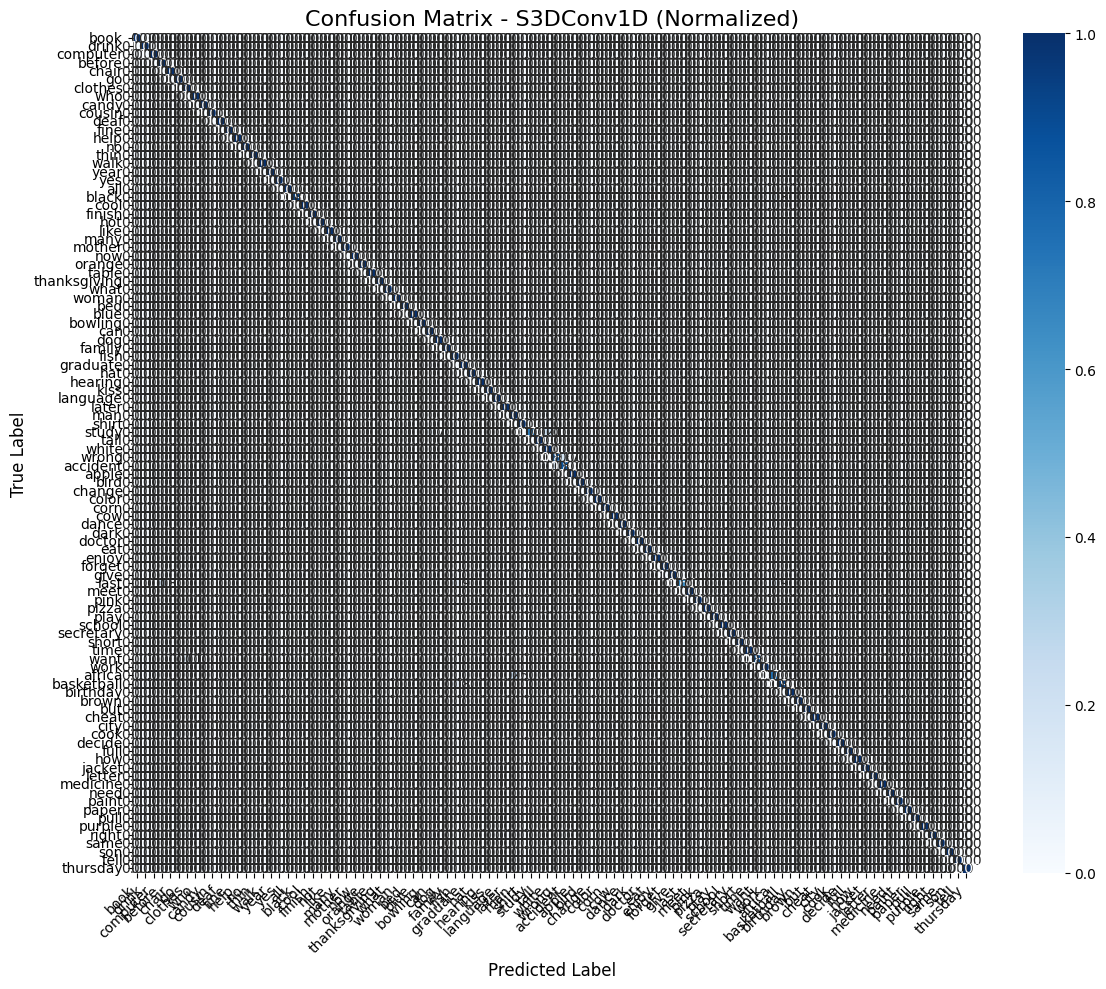

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import json
import pandas as pd
import numpy as np
import os

# --- Load label mapping ---
raw_frame_dir = "/kaggle/working/frames_rgb"
with open(os.path.join(raw_frame_dir, "label_to_idx.json"), "r") as f:
    label_to_idx = json.load(f)

# --- Label names sorted by index ---
labels = [label for label, idx in sorted(label_to_idx.items(), key=lambda x: x[1])]

# --- Load confusion matrix ---
cm = np.load("s3dConv1d_confusion_matrix.npy")

# --- Normalize (optional) ---
cm_normalized = cm.astype(np.float32) / cm.sum(axis=1, keepdims=True)
cm_normalized = np.nan_to_num(cm_normalized)

# --- Plot heatmap ---
plt.figure(figsize=(12, 10))
sns.heatmap(pd.DataFrame(cm_normalized, index=labels, columns=labels),
            annot=True, fmt=".2f", cmap="Blues", cbar=True,
            xticklabels=labels, yticklabels=labels,
            linewidths=0.5, linecolor='gray')

plt.title("Confusion Matrix - S3DConv1D (Normalized)", fontsize=16)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.savefig("/kaggle/working/s3dConv1d_confusion_matrix.png", dpi=300)
plt.show()

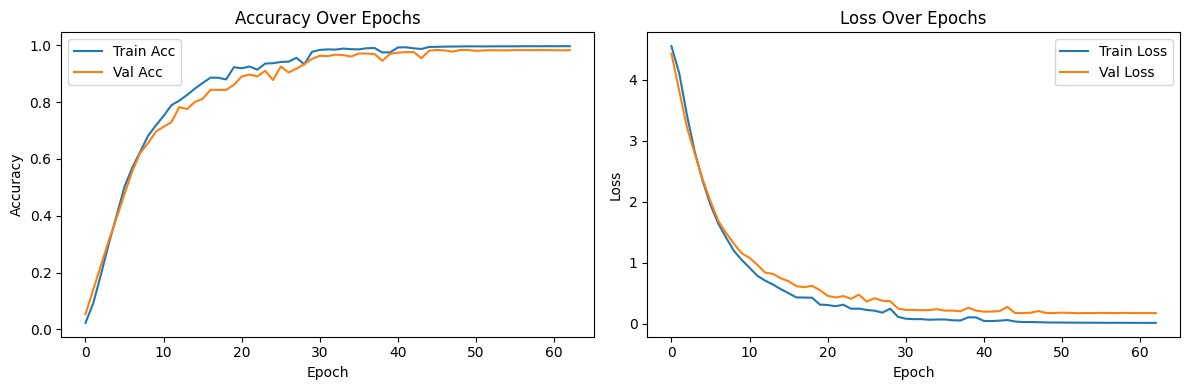

In [17]:
import matplotlib.pyplot as plt
import os


def plot_training_history(history, save_path="/kaggle/working/s3dConv1d_training_plot.png"):
    if history is None or not hasattr(history, "history"):
        print("Invalid training history object.")
        return

    plt.figure(figsize=(12, 4))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history.get('accuracy', []), label='Train Acc')
    plt.plot(history.history.get('val_accuracy', []), label='Val Acc')
    plt.title("Accuracy Over Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history.get('loss', []), label='Train Loss')
    plt.plot(history.history.get('val_loss', []), label='Val Loss')
    plt.title("Loss Over Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.show()

# Usage after model.fit(...)
plot_training_history(history)

**Evaluation block for INT8 Qunatized model**

In [18]:
import os
import numpy as np
import tensorflow as tf

# === Paths ===
raw_frame_dir = "/kaggle/working/frames_rgb"  # Updated to match WLASL pipeline output
quant_model_path = os.path.join(raw_frame_dir, "s3d_conv1d_int8_100.tflite")
float32_model_path = os.path.join(raw_frame_dir, "s3d_conv1d_float32_100.tflite")

# === Load Representative Calibration Dataset ===
# Use training split as representative data
X_calib = np.load(os.path.join(raw_frame_dir, "X_test.npy")).astype(np.float32)

# === Representative Dataset Generator ===
def representative_data_gen():
    for i in range(len(X_calib)):
        yield [X_calib[i:i+1]]  # shape: (1, 24, 64, 64, 1)

# === Load Your Trained Keras Model ===
model = tf.keras.models.load_model("/kaggle/working/best_S3D_conv1d.h5")

# === INT8 Quantization for OpenMV AE3 ===
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_data_gen
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

quant_tflite_model = converter.convert()
with open(quant_model_path, 'wb') as f:
    f.write(quant_tflite_model)

# === Float32 Model for Comparison ===
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.inference_input_type = tf.float32
converter.inference_output_type = tf.float32

float32_tflite_model = converter.convert()
with open(float32_model_path, 'wb') as f:
    f.write(float32_tflite_model)

# === Feedback ===
print(f"✅ INT8 model saved at: {quant_model_path} ({os.path.getsize(quant_model_path)/1024:.1f} KB)")
print(f"📦 Float32 model saved at: {float32_model_path} ({os.path.getsize(float32_model_path)/1024:.1f} KB)")

Saved artifact at '/tmp/tmp_9tl6ip9'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 24, 64, 64, 1), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 100), dtype=tf.float32, name=None)
Captures:
  139168752815376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139168752816720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139168752827472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139168752818448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139168752817872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139168752819216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139168752818640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139168752819984: TensorSpec(shape=(), dtype=tf.resource, name=None)


/usr/local/lib/python3.11/dist-packages/tensorflow/lite/python/convert.py:997: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1772451321.299883      38 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1772451321.299913      38 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1772451321.326610      38 mlir_graph_optimization_pass.cc:401] MLIR V1 optimization pass is not enabled
fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8


Saved artifact at '/tmp/tmprc7zrlzo'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 24, 64, 64, 1), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 100), dtype=tf.float32, name=None)
Captures:
  139168752815376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139168752816720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139168752827472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139168752818448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139168752817872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139168752819216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139168752818640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139168752819984: TensorSpec(shape=(), dtype=tf.resource, name=None)


W0000 00:00:1772451784.671520      38 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1772451784.671546      38 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.


✅ INT8 model saved at: /kaggle/working/frames_rgb/s3d_conv1d_int8_100.tflite (970.2 KB)
📦 Float32 model saved at: /kaggle/working/frames_rgb/s3d_conv1d_float32_100.tflite (3557.5 KB)


In [19]:
import os
import numpy as np
import tensorflow as tf

# === Paths ===
raw_frame_dir = "/kaggle/working/frames_rgb"
quant_model_path = os.path.join(raw_frame_dir, "s3d_conv1d_int8_100.tflite")

# === Load INT8 Model ===
interpreter = tf.lite.Interpreter(model_path=quant_model_path)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# === Load Representative Dataset ===
X_calib = np.load(os.path.join(raw_frame_dir, "X_test.npy")).astype(np.float32)
y_calib = np.load(os.path.join(raw_frame_dir, "y_test.npy"))

# === Quantize Input ===
def preprocess_input(x):
    scale, zero_point = input_details[0]['quantization']
    return (x / scale + zero_point).astype(np.int8)

# === Dequantize Output ===
def dequantize_output(x):
    scale, zero_point = output_details[0]['quantization']
    return (x.astype(np.float32) - zero_point) * scale

# === Softmax Function ===
def softmax(x):
    e_x = np.exp(x - np.max(x))
    return e_x / e_x.sum(axis=-1, keepdims=True)

# === Run Inference ===
y_probs_int8 = []
for x in X_calib:
    x_input = preprocess_input(x[np.newaxis, ...])  # shape: (1, 24, 64, 64, 1)
    interpreter.set_tensor(input_details[0]['index'], x_input)
    interpreter.invoke()
    output = interpreter.get_tensor(output_details[0]['index'])
    output_dequant = dequantize_output(output)
    y_probs_int8.append(softmax(output_dequant[0]))

y_probs_int8 = np.array(y_probs_int8)

# === Softmax Sanity Check ===
softmax_sums = np.sum(y_probs_int8, axis=1)
print("📊 Softmax sum stats:")
print("Mean:", np.mean(softmax_sums))
print("Std Dev:", np.std(softmax_sums))
print("Min:", np.min(softmax_sums))
print("Max:", np.max(softmax_sums))

# === Accuracy Evaluation ===
y_pred = np.argmax(y_probs_int8, axis=1)
accuracy = np.mean(y_pred == y_calib)
print("✅ INT8 model accuracy on calibration set:", round(accuracy * 100, 2), "%")


# === Classification Report ===
print("📋 Classification Report:")
print(classification_report(y_calib, y_pred, zero_division=0))

# === Confusion Matrix ===
print("📊 Confusion Matrix:")
print(confusion_matrix(y_calib, y_pred))

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


📊 Softmax sum stats:
Mean: 1.0
Std Dev: 1.1636816e-07
Min: 0.99999964
Max: 1.0000002
✅ INT8 model accuracy on calibration set: 97.77 %
📋 Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00        11
           2       1.00      1.00      1.00        12
           3       0.89      1.00      0.94        16
           4       1.00      1.00      1.00         9
           5       1.00      1.00      1.00        15
           6       0.88      1.00      0.93         7
           7       1.00      1.00      1.00        15
           8       1.00      1.00      1.00        14
           9       1.00      1.00      1.00        14
          10       1.00      1.00      1.00        13
          11       1.00      1.00      1.00        12
          12       1.00      1.00      1.00        17
          13       1.00      1.00      1.00        13
          14       0.95      